In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import networkx as nx
from torch_geometric.nn import GATConv
from torch_geometric.utils import from_networkx
from transformers import BertTokenizer, BertModel
import collections
from collections import deque, namedtuple   
import random
import gymnasium as gym          
from gymnasium import spaces     
import matplotlib.pyplot as plt
from tqdm import tqdm
import sys

In [2]:
# Configuration & Hyperparameters
BATCH_SIZE = 32
GAMMA = 0.95
LR = 1e-4
MEMORY_SIZE = 2000
Transition = namedtuple('Transition', ('state', 'edge_index', 'actions', 'reward', 'next_state', 'done'))
device = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:

class GATEncoder(nn.Module):
    def __init__(self, in_channels=773, hidden_channels=64, out_channels=32):
        super(GATEncoder, self).__init__()
        # Layer 1: Captures immediate neighbors (8 heads for diverse attention)
        self.gat1 = GATConv(in_channels, hidden_channels, heads=8, dropout=0.6)
        
        # Layer 2: Captures 2-hop neighborhoods (neighbors of neighbors)
        self.gat2 = GATConv(hidden_channels * 8, hidden_channels, heads=4, dropout=0.6)
        
        # Layer 3: Captures 3-hop neighborhoods and compresses to final 32D state
        self.gat3 = GATConv(hidden_channels * 4, out_channels, heads=1, concat=False)

    def forward(self, x, edge_index):
        # Layer 1 with ELU activation and Dropout
        x = F.dropout(x, p=0.6, training=self.training)
        x = F.elu(self.gat1(x, edge_index))
        
        # Layer 2
        x = F.dropout(x, p=0.6, training=self.training)
        x = F.elu(self.gat2(x, edge_index))
        
        # Layer 3 (Final representation)
        x = self.gat3(x, edge_index)
        return x

In [4]:

class DeepAgent(nn.Module):
    def __init__(self, input_dim=32, n_actions=11):
        super(DeepAgent, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, n_actions)
        )

    def forward(self, state_embedding):
        return self.network(state_embedding)
class QMixer(nn.Module):
    def __init__(self, n_agents=2, state_dim=32):
        super(QMixer, self).__init__()
        self.hyper_w = nn.Linear(state_dim, n_agents)
        self.hyper_b = nn.Linear(state_dim, 1)

    def forward(self, agent_qs, state):
        # agent_qs: [batch, n_agents]
        w = torch.abs(self.hyper_w(state)) # Ensure monotonicity
        b = self.hyper_b(state)
        q_tot = torch.sum(w * agent_qs, dim=1, keepdim=True) + b
        return q_tot

In [5]:

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')
def get_text_embedding(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    outputs = model(**inputs)
    # Use the mean of the last hidden state as the feature vector
    return outputs.last_hidden_state.mean(dim=1).detach().numpy()



Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [6]:
def load_rumour_with_features(filename):
    #print("Tanvi")
    base_path = r"C:\Users\Tanvi Dhola\OneDrive\Desktop\DL\data\rumor_detection_acl2017\twitter16"
    tree_file = os.path.join(base_path, "tree", filename)
    source_file = os.path.join(base_path, "source.txt")
    label_file = os.path.join(base_path, "label.txt")

    G = nx.DiGraph()
    root_id = os.path.splitext(filename)[0].strip()

    label_dict = {}
    if os.path.exists(label_file):
        with open(label_file, 'r', encoding='utf-8') as f:
            for line in f:
                if ':' not in line: continue
                lbl, tid = line.split(':', 1)
                label_dict[tid.strip()] = lbl.strip()

    root_label_str = label_dict.get(root_id, "unverified")
    is_rumor = 1.0 if root_label_str in ["false", "unverified"] else 0.0

  
    source_text_vector = np.zeros(768)
    if os.path.exists(source_file):
        with open(source_file, 'r', encoding='utf-8') as f:
            for line in f:
                if line.startswith(root_id):
                    text = line.split('\t')[1].strip()
                    source_text_vector = get_text_embedding(text)
                    break

  
    with open(tree_file, 'r', encoding='utf-8', errors='ignore') as f:
        #print("Hello1")
        for line in f:
            if '->' not in line: continue
            try:
                # Parsing logic to extract parent, child, and delay
                parts = line.replace("[", "").replace("]", "").replace("'", "").split("->")
                left = parts[0].split(",")
                right = parts[1].split(",")
                
                parent, child = left[0].strip(), right[0].strip()
                delay = float(right[2].strip())
                
                G.add_edge(parent, child, delay=delay)
            except: continue

    # Calculate structural metrics for the whole graph
    clustering = nx.clustering(G.to_undirected())
    betweenness = nx.betweenness_centrality(G)
    #print("Hello2")
    for node in G.nodes():
        deg = G.degree(node)
        delay = G.nodes[node].get('delay', 0.0)
        cluster_feat = clustering.get(node, 0.0)
        bet_feat = betweenness.get(node, 0.0)
        
        # BERT text features (only root gets the vector)
        if node == root_id:
            # L2 Normalization for BERT vector
            norm = np.linalg.norm(source_text_vector)
            text_feat = source_text_vector / norm if norm > 0 else source_text_vector
        else:
            text_feat = np.zeros(768)
        label_feat = np.array([is_rumor])
        #print("Hello3")
        # NEW TOTAL DIMENSION: 768 (BERT) + 1 (delay) + 1 (deg) + 1 (cluster) + 1 (betweenness) + 1 (label) = 773
        G.nodes[node]['x'] = np.concatenate([
            text_feat, [delay, deg, cluster_feat, bet_feat], label_feat
        ]).astype(np.float32)
    #print("before")
    print(f"Loaded {root_id} | Nodes: {G.number_of_nodes()} | Features: 773")
    return G, root_id, is_rumor

In [ ]:
class RumorEnv(gym.Env):
    def __init__(self, G, root_id, is_rumor, gat_encoder, use_coop=True,use_gnn=True):
        super().__init__()
        # Base Data
        self.original_G = G.copy()
        self.root_id = root_id
        self.is_rumor = is_rumor
        self.use_coop = use_coop
        self.gat_encoder = gat_encoder
        self.use_gnn = use_gnn
        self.node_to_idx = {str(node): i for i, node in enumerate(self.original_G.nodes())}
        
        self.min_detection_threshold = 5 
        # 0: None, 1: High-Degree, 2: High-Betweenness, 3: High-GAT-Attention, 4: Frontier
        self.action_space = spaces.MultiDiscrete([5, 5])
        
        # Observation space matches the 32D embedding output of your GAT
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(32,), dtype=np.float32)

        # Sort propagation events by delay
        self.events = [(d['delay'], u, v) for u, v, d in G.edges(data=True)]
        self.events.sort(key=lambda x: x[0])
        
        self.reset()

    def _get_obs(self):
        nodes = list(self.G.nodes())
        x_list = []
        for n in nodes:
            status = -1.0 if n in self.blocked else 1.0 if n in self.infected else 0.0
            feat = np.concatenate([self.original_G.nodes[n]['x'], [status]])
            x_list.append(feat)
        
        x_np = np.array(x_list, dtype=np.float32) 
        x = torch.from_numpy(x_np).to(device)
        
        if self.use_gnn:
            edge_index = from_networkx(nx.Graph(self.G)).edge_index.to(device)
            node_embeddings = self.gat_encoder(x, edge_index)
        else:
            if not hasattr(self, 'baseline_proj'):
                self.baseline_proj = torch.nn.Linear(774, 32).to(device)
            node_embeddings = self.baseline_proj(x)
    
        infected_indices = [self.node_to_idx[str(n)] for n in self.infected if str(n) in self.node_to_idx]
        if not infected_indices:
            return np.zeros(32, dtype=np.float32)
        
        return node_embeddings[infected_indices].mean(dim=0).detach().cpu().numpy()

    def get_gat_attention_scores(self, node_features, edge_index):
       
        self.gat_encoder.eval()
        with torch.no_grad():
            out, (edge_idx, att_weights) = self.gat_encoder.gat1(
                node_features, edge_index, return_attention_weights=True
            )
            mean_att = att_weights.mean(dim=1)
            
            num_nodes = node_features.size(0)
            node_importance = torch.zeros(num_nodes,device=node_features.device)
            # Accumulate importance per target node
            node_importance.scatter_add_(0, edge_idx[1], mean_att)
            
            return node_importance

    def step(self, actions):
        mod_action, fc_action = actions
        reward = 0.0
        pre_infected = len(self.infected)
        
        if len(self.infected) >= self.min_detection_threshold:
            # Need features and edge_index for the Attention-based strategy (Action 3)
            nodes = list(self.G.nodes())
            x_list = [np.concatenate([self.original_G.nodes[n]['x'], [1.0 if n in self.infected else 0.0]]) for n in nodes]
            x = torch.tensor(np.array(x_list), dtype=torch.float32).to(device)
            edge_index = from_networkx(nx.Graph(self.G)).edge_index.to(device)
            
            att_scores = self.get_gat_attention_scores(x, edge_index)
            
            reward += self._execute_strategy(mod_action, "moderator", att_scores, nodes)
            reward += self._execute_strategy(fc_action, "fact_checker", att_scores, nodes)
            
            if self.use_coop and mod_action > 0 and fc_action > 0:
                reward += 50.0 # Cooperation Bonus

        #  Simulate Natural Propagation
        self.current_time += 1.0
        new_nodes = []
        while self.event_idx < len(self.events) and self.events[self.event_idx][0] <= self.current_time:
            delay, parent, child = self.events[self.event_idx]
            self.event_idx += 1
            if parent in self.infected and child not in self.infected and child not in self.blocked:
                self.infected.add(child)
                new_nodes.append(child)
        # Penalty = (Base + Depth-Factor) per node
        for node in new_nodes:
            try:
                depth = nx.shortest_path_length(self.original_G, source=self.root_id, target=node)
                reward -= (2.0 + (1.0 * depth))
            except:
                reward -= 2.0

        # Success/Failure Conditions
        if self.is_rumor == 0.0 and (mod_action > 0 or fc_action > 0):
            reward -= 20.0 # Misinformation mitigation on True News is a failure
        if len(self.infected) == 0:
            reward += 100.0 # Bonus for total containment

        self.step_count += 1
        terminated = self.event_idx >= len(self.events)
        truncated = self.step_count >= 200

        return self._get_obs(), reward, terminated, truncated, {}

    def _execute_strategy(self, action_idx, role, att_scores, node_list):
        if action_idx == 0: return 0.0
        
        candidates = list(self.infected)
        if not candidates: return 0.0
        
        target = None
        if action_idx == 1: # High Degree
            target = max(candidates, key=lambda n: self.original_G.degree(n))
        elif action_idx == 2: # High Betweenness
            target = max(candidates, key=lambda n: self.original_G.nodes[n].get('betweenness', 0))
        elif action_idx == 3: # highest attention score
            target = max(candidates, key=lambda n: att_scores[node_list.index(n)].item())
        elif action_idx == 4: # Frontier Target
            target = max(candidates, key=lambda n: self.original_G.nodes[n].get('delay', 0))

        # Check: Never block the root node
        if target and target != self.root_id:
            self.infected.discard(target)
            self.blocked.add(target)
            return 25.0 if role == "moderator" else 30.0
        
        return -1.0

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.G = self.original_G.copy()
        self.infected = {self.root_id}
        self.blocked = set()
        self.current_time = 0.0
        self.step_count = 0
        self.event_idx = 0
        return self._get_obs(), {}

In [8]:
def load_all_rumors():
    base_path = r"C:\Users\Tanvi Dhola\OneDrive\Desktop\DL\data\rumor_detection_acl2017\twitter16"
    tree_dir = os.path.join(base_path, "tree")
    
    tree_files = [f for f in os.listdir(tree_dir) if f.endswith(".txt")]
    print(f"Found {len(tree_files)} rumors in Twitter16.")

    all_data = []
    files_to_use = random.sample(tree_files,30)
    for filename in files_to_use:
        try:
            G, root_id, is_rumor = load_rumour_with_features(filename)
            if G.number_of_nodes() > 5:   # ignore tiny graphs
                all_data.append((G, root_id, is_rumor))
        except:
            continue
            
    print(f" Successfully loaded {len(all_data)} valid rumor trees")
    return all_data

In [9]:
def fix_twitter16_format(data_list):
    fixed_data = []
    print(f"Cleaning {len(data_list)} rumors...")
    
    for i, (G, root, label) in enumerate(data_list):
 
        if G.number_of_nodes() == 0:
            continue
        if root not in G.nodes():
            
            actual_root = list(G.nodes())[0]
        else:
            actual_root = root        
        mapping = {node: idx for idx, node in enumerate(G.nodes())}
        G_int = nx.relabel_nodes(G, mapping)
        new_root_int = mapping[actual_root]
        first_node_data = G_int.nodes[0]
        if 'x' not in first_node_data:
            pass 

        fixed_data.append((G_int, new_root_int, label))
        
    print(f"Successfully cleaned {len(fixed_data)} rumors.")
    return fixed_data

all_data = load_all_rumors()
print(f"Successfully loaded {len(all_data)} rumors. Starting training...")
all_data_fixed = fix_twitter16_format(all_data)
sample_G = all_data_fixed[0][0]
print("Do nodes have features?", 'x' in sample_G.nodes[0])

Found 818 rumors in Twitter16.
Loaded 745236050407194624 | Nodes: 98 | Features: 773
Loaded 661120256732041216 | Nodes: 182 | Features: 773
Loaded 614494170590367744 | Nodes: 895 | Features: 773
Loaded 693843042546106369 | Nodes: 351 | Features: 773
Loaded 765359928361922560 | Nodes: 671 | Features: 773
Loaded 544374511194632192 | Nodes: 207 | Features: 773
Loaded 553476880339599360 | Nodes: 101 | Features: 773
Loaded 714503380476026880 | Nodes: 339 | Features: 773
Loaded 620916279608651776 | Nodes: 390 | Features: 773
Loaded 666335363099660288 | Nodes: 570 | Features: 773
Loaded 524962142563610625 | Nodes: 179 | Features: 773
Loaded 552792913910833152 | Nodes: 100 | Features: 773
Loaded 687984820815851521 | Nodes: 273 | Features: 773
Loaded 701872343736520704 | Nodes: 821 | Features: 773
Loaded 647464349611589632 | Nodes: 151 | Features: 773
Loaded 674014933235859456 | Nodes: 225 | Features: 773
Loaded 740748123581087745 | Nodes: 600 | Features: 773
Loaded 675005503160901632 | Nodes: 

In [10]:
def evaluate_twitter16_subset(all_twitter16_data, model_path, num_samples=10, use_gnn=True, use_coop=True):
    
    gat = GATEncoder(in_channels=774, out_channels=32).to("cpu")
    mod = DeepAgent(input_dim=32, n_actions=5).to("cpu")
    fc = DeepAgent(input_dim=32, n_actions=5).to("cpu")
   
    print(f"DEBUG: Loading weights from {model_path}...")
    checkpoint = torch.load(model_path, map_location=device)
    gat.load_state_dict(checkpoint['gat_state_dict'])
    mod.load_state_dict(checkpoint['mod_state_dict'])
    fc.load_state_dict(checkpoint['fc_state_dict'])
    
    gat.eval(); mod.eval(); fc.eval()

    interaction_stats = {"Both Acted": 0, "Moderator Only": 0, "Fact-Checker Only": 0, "Neither": 0}
    total_rewards = []
    total_steps = 0
    print(f"Starting evaluation on {len(all_twitter16_data)} random rumors...")
    with torch.no_grad():
        for i, (G, root_id, is_rumor) in enumerate(all_twitter16_data):
            env = RumorEnv(G, root_id, is_rumor, gat, use_gnn=use_gnn, use_coop=use_coop)
            state, _ = env.reset()
            ep_reward = 0
            done = False
            steps = 0
            
            while not done and steps < 30:
                s_tensor = torch.tensor(state, dtype=torch.float32).to("cpu").unsqueeze(0)
                q_m = mod(s_tensor)
                q_f = fc(s_tensor)
                q_m[0, 0] = -float('inf')
                q_f[0, 0] = -float('inf')
                            
                a_m = q_m.argmax().item() 
                a_f = q_f.argmax().item() 
                
               
                if a_m > 0 and a_f > 0:
                    interaction_stats["Both Acted"] += 1
                elif a_m > 0:
                    interaction_stats["Moderator Only"] += 1
                elif a_f > 0:
                    interaction_stats["Fact-Checker Only"] += 1
                else:
                    interaction_stats["Neither"] += 1
                
                total_steps += 1
                state, reward, done, _, _ = env.step([a_m, a_f])
                if steps<3:
                    print(f"Step {steps} | State Mean: {state.mean():.4f} | Mod Action: {a_m} | FC Action: {a_f} | Step Reward: {reward}")
                ep_reward += reward
                steps += 1
            
            total_rewards.append(ep_reward)
            
            if (i+1) % 20 == 0:
                print(f"Processed {i+1}/{len(all_twitter16_data)} | Current Mean Reward: {np.mean(total_rewards):.2f}")
    if total_steps > 0:
        for key in interaction_stats:
            interaction_stats[key] = (interaction_stats[key] / total_steps) * 100


    return total_rewards, interaction_stats


In [12]:
print("Evaluating full model...")
path = r"C:\Users\Tanvi Dhola\OneDrive\Desktop\DL\code\Full_model.pth"
rew_full, int_full = evaluate_twitter16_subset(all_data_fixed,model_path = path,num_samples=10, use_gnn=True, use_coop=True)

Evaluating full model...
DEBUG: Loading weights from C:\Users\Tanvi Dhola\OneDrive\Desktop\DL\code\Full_model.pth...
Starting evaluation on 30 random rumors...
Step 0 | State Mean: -0.0379 | Mod Action: 2 | FC Action: 3 | Step Reward: -3.0
Step 1 | State Mean: -0.0379 | Mod Action: 2 | FC Action: 3 | Step Reward: 0.0
Step 2 | State Mean: -0.0379 | Mod Action: 2 | FC Action: 3 | Step Reward: 0.0


E:\Anaconda3\envs\rumor_env\lib\site-packages\torch_geometric\utils\convert.py:278: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:256.)
  data_dict[key] = torch.as_tensor(value)


Step 0 | State Mean: -0.0641 | Mod Action: 2 | FC Action: 3 | Step Reward: -3.0
Step 1 | State Mean: -0.0641 | Mod Action: 2 | FC Action: 3 | Step Reward: 0.0
Step 2 | State Mean: -0.0641 | Mod Action: 2 | FC Action: 3 | Step Reward: 0.0
Step 0 | State Mean: -0.4877 | Mod Action: 2 | FC Action: 3 | Step Reward: -324.0
Step 1 | State Mean: -0.4991 | Mod Action: 2 | FC Action: 3 | Step Reward: -248.0
Step 2 | State Mean: -0.4934 | Mod Action: 2 | FC Action: 3 | Step Reward: 54.0
Step 0 | State Mean: -0.1615 | Mod Action: 2 | FC Action: 3 | Step Reward: -55.0
Step 1 | State Mean: -0.1582 | Mod Action: 2 | FC Action: 3 | Step Reward: 59.0
Step 2 | State Mean: -0.1582 | Mod Action: 2 | FC Action: 3 | Step Reward: 28.0
Step 0 | State Mean: -0.2771 | Mod Action: 2 | FC Action: 3 | Step Reward: -27.0
Step 1 | State Mean: -0.2897 | Mod Action: 2 | FC Action: 3 | Step Reward: -28.0
Step 2 | State Mean: -0.2803 | Mod Action: 2 | FC Action: 3 | Step Reward: 16.0
Step 0 | State Mean: -0.0715 | Mod 

In [13]:
print("Running No GNN Model...")
path = r"C:\Users\Tanvi Dhola\OneDrive\Desktop\DL\code\No_gnn.pth"
rew_no_gnn, int_no_gnn = evaluate_twitter16_subset(all_data_fixed, model_path = path,num_samples=10, use_gnn=False, use_coop=True)
print("Running No Coop Model...")
path = r"C:\Users\Tanvi Dhola\OneDrive\Desktop\DL\code\No_coop.pth"
rew_no_coop, int_no_coop = evaluate_twitter16_subset(all_data_fixed,model_path = path,num_samples=10, use_gnn=True, use_coop=False)

Running No GNN Model...
DEBUG: Loading weights from C:\Users\Tanvi Dhola\OneDrive\Desktop\DL\code\No_gnn.pth...
Starting evaluation on 30 random rumors...
Step 0 | State Mean: 0.1669 | Mod Action: 4 | FC Action: 3 | Step Reward: -3.0
Step 1 | State Mean: 0.1669 | Mod Action: 4 | FC Action: 3 | Step Reward: 0.0
Step 2 | State Mean: 0.1669 | Mod Action: 4 | FC Action: 3 | Step Reward: 0.0
Step 0 | State Mean: 0.3443 | Mod Action: 4 | FC Action: 3 | Step Reward: -3.0
Step 1 | State Mean: 0.3443 | Mod Action: 4 | FC Action: 3 | Step Reward: 0.0
Step 2 | State Mean: 0.3443 | Mod Action: 4 | FC Action: 3 | Step Reward: 0.0
Step 0 | State Mean: 0.0139 | Mod Action: 4 | FC Action: 3 | Step Reward: -324.0
Step 1 | State Mean: 0.0082 | Mod Action: 4 | FC Action: 3 | Step Reward: -248.0
Step 2 | State Mean: 0.0020 | Mod Action: 4 | FC Action: 3 | Step Reward: 54.0
Step 0 | State Mean: 0.1737 | Mod Action: 4 | FC Action: 3 | Step Reward: -55.0
Step 1 | State Mean: 0.1046 | Mod Action: 4 | FC Actio

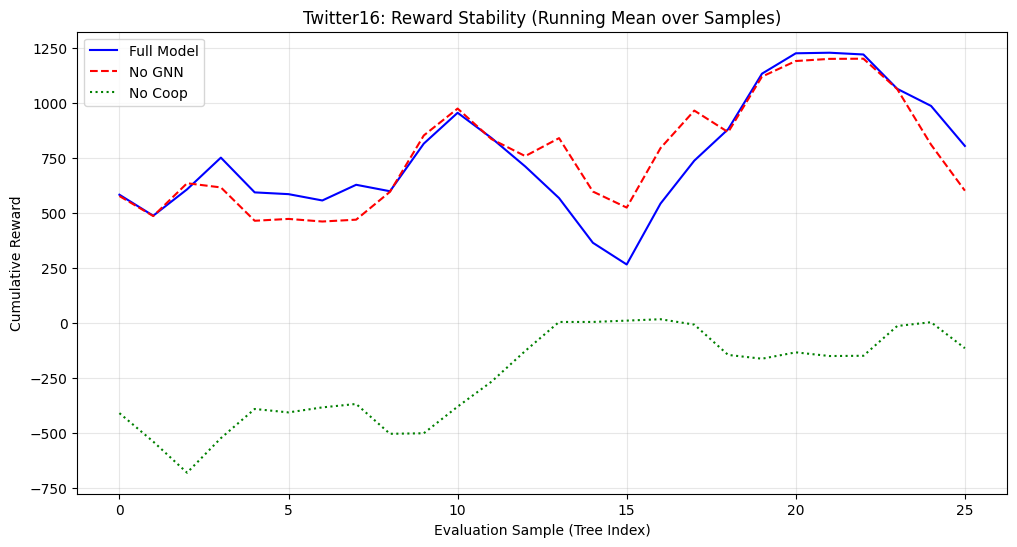

In [15]:
def running_mean(x, N=5):
    return np.convolve(x, np.ones(N)/N, mode='valid')

plt.figure(figsize=(12, 6))
plt.plot(running_mean(rew_full), label='Full Model', color='blue')
plt.plot(running_mean(rew_no_gnn), label='No GNN', color='red', linestyle='--')
plt.plot(running_mean(rew_no_coop), label='No Coop', color='green', linestyle=':')
plt.title('Twitter16: Reward Stability (Running Mean over Samples)')
plt.xlabel('Evaluation Sample (Tree Index)')
plt.ylabel('Cumulative Reward')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("twitter16_reward_stability.png")
plt.show()

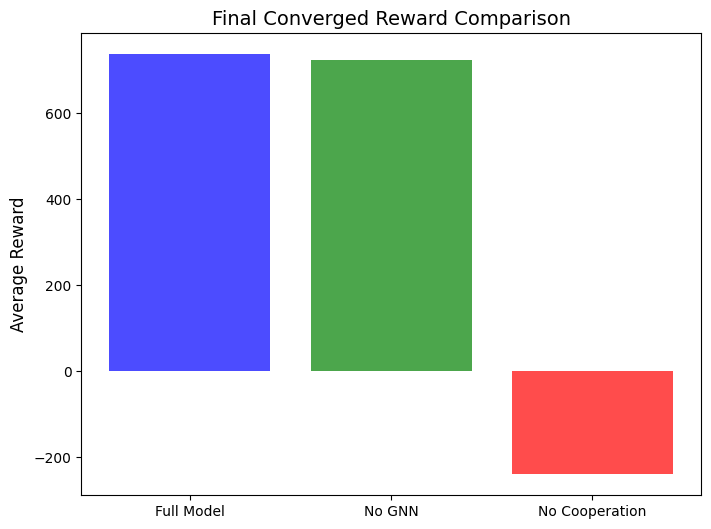

In [18]:

labels = ['Full Model', 'No GNN', 'No Cooperation']
means = [np.mean(rew_full), np.mean(rew_no_gnn), np.mean(rew_no_coop)]

sorted_idx = np.argsort(means)[::-1]
sorted_labels = [labels[i] for i in sorted_idx]
sorted_means = [means[i] for i in sorted_idx]

plt.figure(figsize=(8, 6))
plt.bar(sorted_labels, sorted_means, color=['blue', 'green', 'red'], alpha=0.7)
plt.title('Final Converged Reward Comparison', fontsize=14)
plt.ylabel('Average Reward', fontsize=12)
plt.savefig('reward_comparison_bar_test.png')